# Testing Multiple Thresholds
Now that we have an established pipeline to compare bulk-to-bulk data and assess agreement with scc scores, we can move to testing multiple parameters and how they influence the values of these comparisons. Here, for multiple resolutions, we'll test the effects of thresholding the data at differing percentiles and will compare these results to SCC scores. Furthermore, we'll compare the results between these threshols and test their agreement to see if higher thresholds are still valid for interpretation.

## Importing

In [1]:
### Importing Cooler Files ###
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress
import ot
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, bin_contact_map, get_cool_name, hic_ot_source_to_targets

# Importing data
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/taghic'
coolers = import_cool_dir(data_dir, 1_000_000)

# Extracting chromosome 1
chr1s = []
map_names = []
for clr in coolers:
    chr1s.append(fetch_region(clr, '1'))
    map_names.append(get_cool_name(clr).split("_")[1])

# Importing SCC data
scc_file = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/mouse_scc_chr1/mouse_chr1_scc.csv'
scc_scores_1mb = pd.read_csv(scc_file, index_col=0)
scc_scores_flatten = scc_scores_1mb.values.flatten()

## Defining Helper Functions

In [2]:
def compare_to_scc(ot_results : list, threshold : int, resolution : int, ot_type : str = "Exact"):
    ''' 
        Converts ot results to a pandas dataframe and uses 
        said dataframe to compare ot loss to scc scores.
        
        This function is very specific to this notebook.

        Parameters
        ----------
        ot_results : list
            List of ot results orderded like map_names.
        threshold : int
            The threshold tested. Used for figure title.
        resolution : int
            The resolution tested. Used for figure title.
        ot_type : str
            Type of ot used. Used for figure title.
            Default = "Exact"
        
        Returns
        -------
        results_df : pd.DataFrame
            Dataframe of ot results with indices based on map_names.
        rsqr : float
            R^2 values of the fit with SCC scores.
    '''

    # Convert to dataframe
    results_df = pd.DataFrame(ot_results, index=map_names, columns=map_names)

    # SCC comparison regression
    ot_results_flatten = results_df.values.flatten()
    regression = linregress(ot_results_flatten, scc_scores_flatten)
    slope = regression.slope
    intercept = regression.intercept
    rsqr = regression.rvalue**2

    # Plotting SCC comparison
    plt.scatter(ot_results_flatten, scc_scores_flatten, label="Data")
    plt.plot(ot_results_flatten, intercept + slope * ot_results_flatten, color='red',
             label=f'Linear fit (R\u00b2 = {rsqr:.3f})')
    plt.xlabel("OT loss")
    plt.ylabel("SCC score")
    plt.title(f"{ot_type} OT loss compared to SCC score (Chr1, res = {resolution}Mb, threshold = {threshold})")
    plt.legend()
    plt.grid(alpha=0.3)

    return results_df, rsqr

def save_df_to_csv(results_df : pd.DataFrame, resolution : int, threshold : int, ot_type : str = "exact"):
    ''' 
        Saves ot results dataframe to a file in specific folder.
        
        This function is very specific to this notebook.

        Parameters
        ----------
        results_df : pd.DataFrame
            Dataframe of ot results.
        resolution : int
            The resolution tested. Used for file name.
        threshold : int
            The threshold tested. Used for file name.
        ot_type : str
            Type of ot used. Used for file name.
            Default = "Exact"
        
        Returns
        -------
        None
    '''

    save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Bulk-to-bulk'
    file_name = f"{ot_type}_bulk_to_bulk_{resolution}mb_{threshold}.csv"
    results_df.to_csv(f"{save_dir}/{file_name}")

    return

def calculate_correspondence(results_df1 : pd.DataFrame, results_df2 : pd.DataFrame, plot : bool = False):
    '''
        Calculates linear R^2 value between two ot result dataframes.

        Parameters
        ----------
        results_df1 : pd.DataFrame
            Dataframe of ot results.
        results_df2 : pd.DataFrame
            Dataframe of ot results.
        plot : bool
            Controls whether the results are plotted.
            Default = False.
        
        Returns
        -------
        rsqr : float
            R^2 value for linear regression between the two datasets.
    '''

    # Flatten values
    flatten1 = results_df1.values.flatten()
    flatten2 = results_df2.values.flatten()

    # Linear regression
    regression = linregress(flatten1, flatten2)
    intercept = regression.intercept
    slope = regression.slope
    rsqr = regression.rvalue**2

    # Plotting regression
    if plot:
        plt.scatter(flatten1, flatten2, label="Data")
        plt.plot(flatten1, intercept + slope * flatten1, color='red',
                label=f'Linear fit (R\u00b2 = {rsqr:.3f})')
        plt.xlabel("OT loss df1")
        plt.ylabel("OT loss df2")
        plt.legend()
        plt.grid(alpha=0.3)

    return rsqr

## Exact Optimal Transport

### Resolution = 8 Mb

In [ ]:
### Binning ###
chr1_binned_8mb = []
for chr1 in chr1s:
    chr1_binned_8mb.append(bin_contact_map(chr1, 8))

<class 'list'>


#### Threshold = 0

In [4]:
### OT ###
exact_8mb_0 = []

for chr1 in chr1_binned_8mb:
    exact_8mb_0.append(hic_ot_source_to_targets(chr1, chr1_binned_8mb, 0, 'raw', 'sum'))

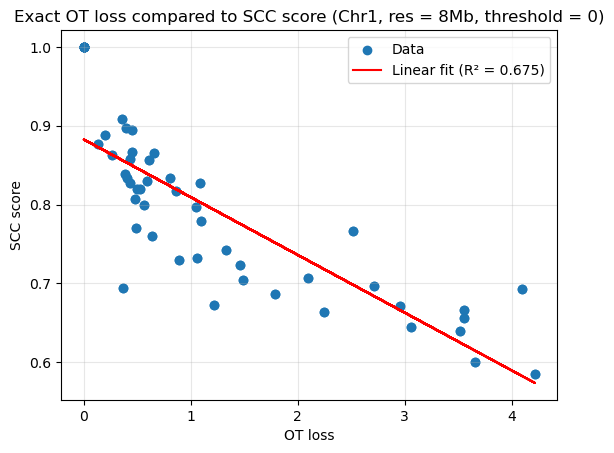

In [5]:
### SCC Comparison ###
df_8mb_0, rsqr_8mb_0 = compare_to_scc(exact_8mb_0, 0, 8)
save_df_to_csv(df_8mb_0, 8, 0)

#### Threshold = 25

In [6]:
### OT ###
exact_8mb_25 = []

for chr1 in chr1_binned_8mb:
    exact_8mb_25.append(hic_ot_source_to_targets(chr1, chr1_binned_8mb, 25, 'percentile', 'sum'))

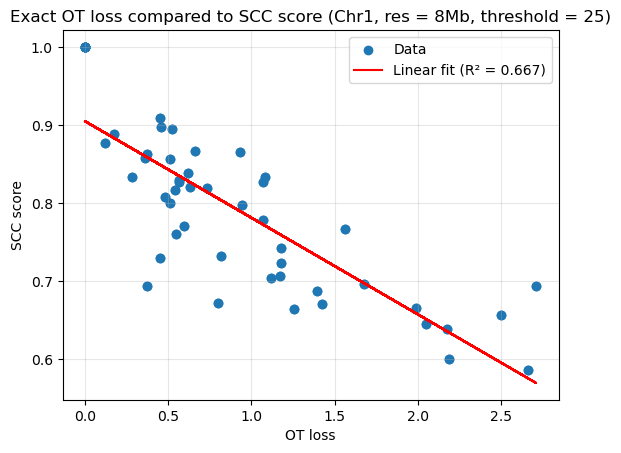

In [7]:
### SCC Comparison ###
df_8mb_25, rsqr_8mb_25 = compare_to_scc(exact_8mb_25, 25, 8)
save_df_to_csv(df_8mb_25, 8, 25)

#### Threshold = 50

In [8]:
### OT ###
exact_8mb_50 = []

for chr1 in chr1_binned_8mb:
    exact_8mb_50.append(hic_ot_source_to_targets(chr1, chr1_binned_8mb, 50, 'percentile', 'sum'))

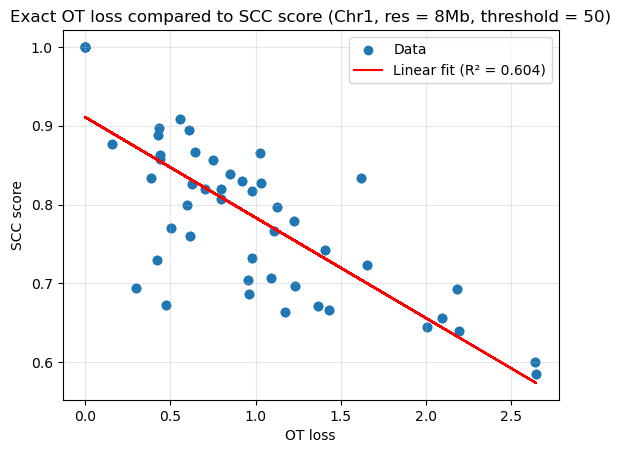

In [9]:
### SCC Comparison ###
df_8mb_50, rsqr_8mb_50 = compare_to_scc(exact_8mb_50, 50, 8)
save_df_to_csv(df_8mb_50, 8, 50)

#### Threshold = 75

In [10]:
### OT ###
exact_8mb_75 = []

for chr1 in chr1_binned_8mb:
    exact_8mb_75.append(hic_ot_source_to_targets(chr1, chr1_binned_8mb, 75, 'percentile', 'sum'))

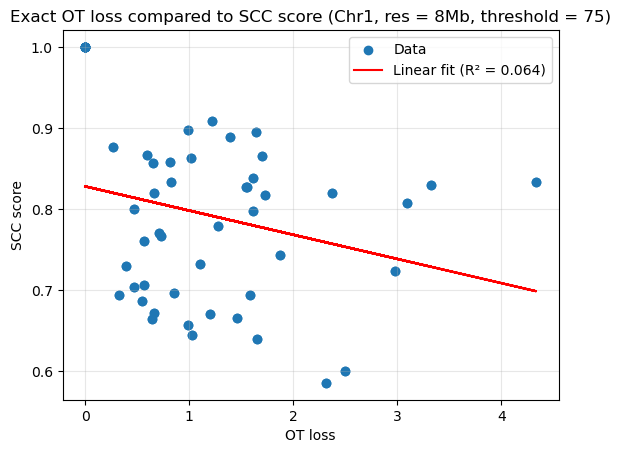

In [11]:
### SCC Comparison ###
df_8mb_75, rsqr_8mb_75 = compare_to_scc(exact_8mb_75, 75, 8)
save_df_to_csv(df_8mb_75, 8, 75)

#### Compiling R^2 values

In [12]:
rsqr_8mb_dict = {
    0 : rsqr_8mb_0,
    25 : rsqr_8mb_25,
    50 : rsqr_8mb_50,
    75 : rsqr_8mb_75
}

### Resolution = 4 Mb

In [15]:
### Binning ###
chr1_binned_4mb = []
for chr1 in chr1s:
    chr1_binned_4mb.append(bin_contact_map(chr1, 4))

#### Threshold = 0

In [16]:
### OT ###
exact_4mb_0 = []

for chr1 in chr1_binned_4mb:
    exact_4mb_0.append(hic_ot_source_to_targets(chr1, chr1_binned_4mb, 0, 'raw', 'sum'))

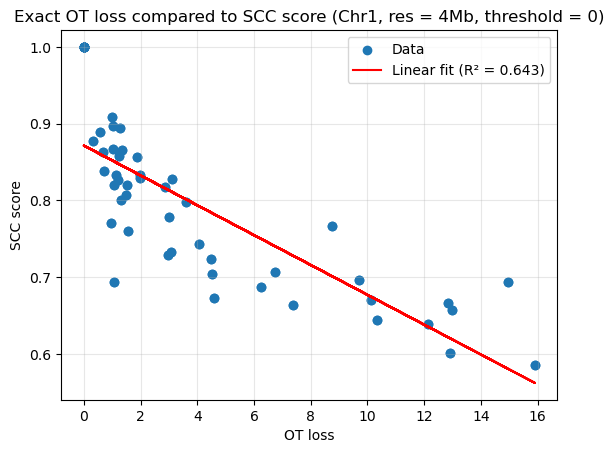

In [48]:
### SCC Comparison ###
df_4mb_0, rsqr_4mb_0 = compare_to_scc(exact_4mb_0, 0, 4)
save_df_to_csv(df_4mb_0, 4, 0)

#### Threshold = 25

In [49]:
### OT ###
exact_4mb_25 = []

for chr1 in chr1_binned_4mb:
    exact_4mb_25.append(hic_ot_source_to_targets(chr1, chr1_binned_4mb, 25, 'percentile', 'sum'))

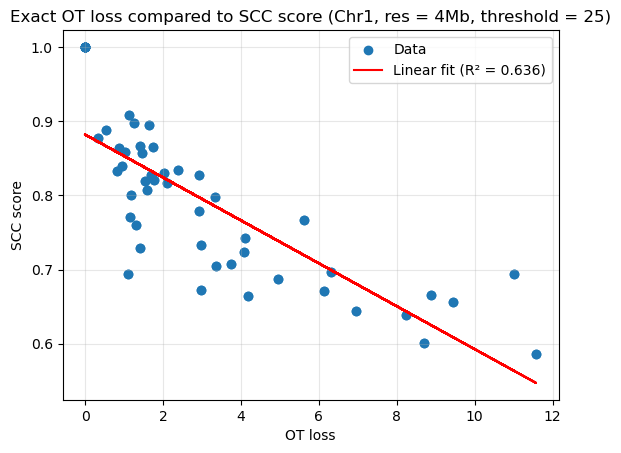

In [50]:
### SCC Comparison ###
df_4mb_25, rsqr_4mb_25 = compare_to_scc(exact_4mb_25, 25, 4)
save_df_to_csv(df_4mb_25, 4, 25)

#### Threshold = 50

In [20]:
### OT ###
exact_4mb_50 = []

for chr1 in chr1_binned_4mb:
    exact_4mb_50.append(hic_ot_source_to_targets(chr1, chr1_binned_4mb, 50, 'percentile', 'sum'))

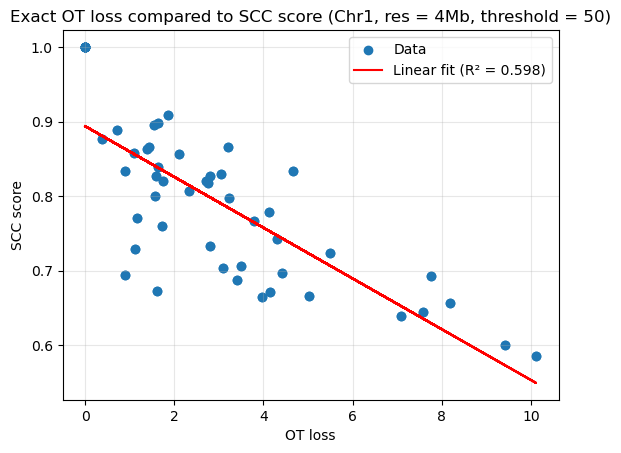

In [51]:
### SCC Comparison ###
df_4mb_50, rsqr_4mb_50 = compare_to_scc(exact_4mb_50, 50, 4)
save_df_to_csv(df_4mb_50, 4, 50)

#### Threshold = 75

In [22]:
### OT ###
exact_4mb_75 = []

for chr1 in chr1_binned_4mb:
    exact_4mb_75.append(hic_ot_source_to_targets(chr1, chr1_binned_4mb, 75, 'percentile', 'sum'))

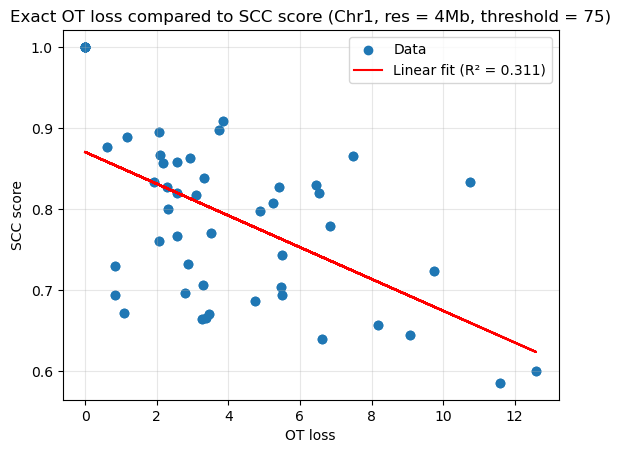

In [52]:
### SCC Comparison ###
df_4mb_75, rsqr_4mb_75 = compare_to_scc(exact_4mb_75, 75, 4)
save_df_to_csv(df_4mb_75, 4, 75)

#### Compiling R^2 values

In [24]:
rsqr_4mb_dict = {
    0 : rsqr_4mb_0,
    25 : rsqr_4mb_25,
    50 : rsqr_4mb_50,
    75 : rsqr_4mb_75
}

### Resolution = 2 Mb

In [25]:
### Binning ###
chr1_binned_2mb = []
for chr1 in chr1s:
    chr1_binned_2mb.append(bin_contact_map(chr1, 2))

#### Threshold = 0

In [26]:
### OT ###
exact_2mb_0 = []

for chr1 in chr1_binned_2mb:
    exact_2mb_0.append(hic_ot_source_to_targets(chr1, chr1_binned_2mb, 0, 'raw', 'sum'))

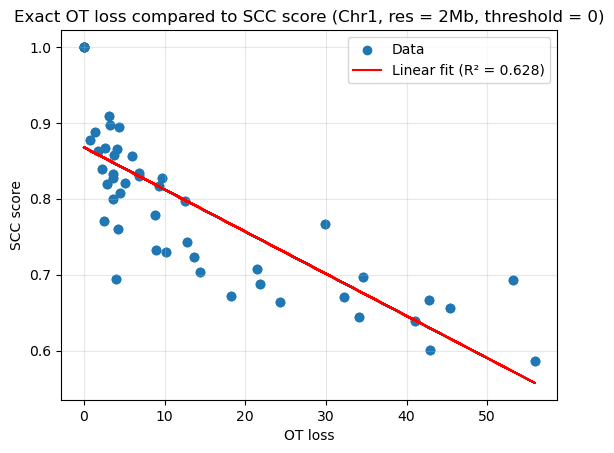

In [53]:
### SCC Comparison ###
df_2mb_0, rsqr_2mb_0 = compare_to_scc(exact_2mb_0, 0, 2)
save_df_to_csv(df_2mb_0, 2, 0)

#### Threshold = 25

In [28]:
### OT ###
exact_2mb_25 = []

for chr1 in chr1_binned_2mb:
    exact_2mb_25.append(hic_ot_source_to_targets(chr1, chr1_binned_2mb, 25, 'percentile', 'sum'))

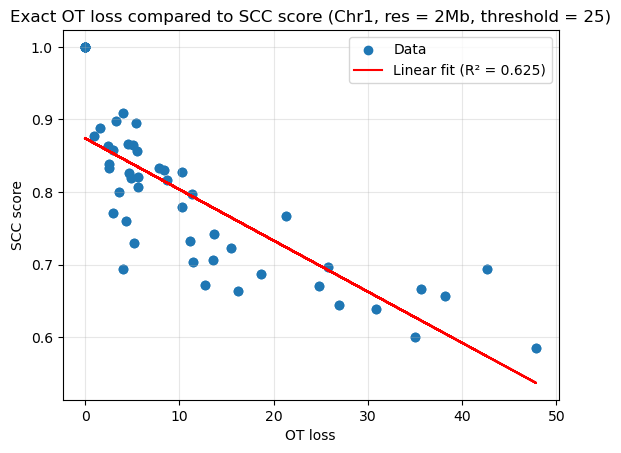

In [54]:
### SCC Comparison ###
df_2mb_25, rsqr_2mb_25 = compare_to_scc(exact_2mb_25, 25, 2)
save_df_to_csv(df_2mb_25, 2, 25)

#### Threshold = 50

In [30]:
### OT ###
exact_2mb_50 = []

for chr1 in chr1_binned_2mb:
    exact_2mb_50.append(hic_ot_source_to_targets(chr1, chr1_binned_2mb, 50, 'percentile', 'sum'))

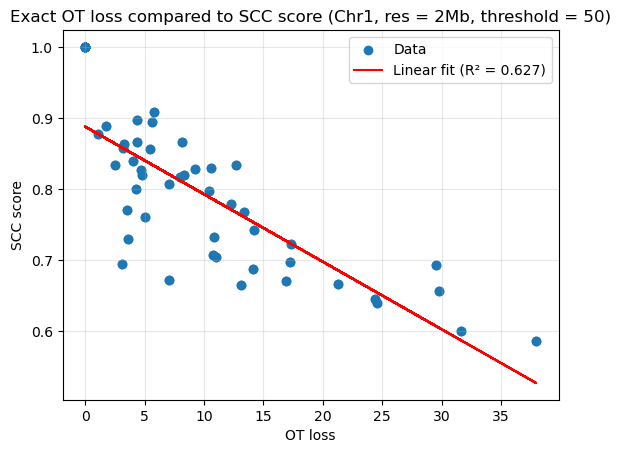

In [55]:
### SCC Comparison ###
df_2mb_50, rsqr_2mb_50 = compare_to_scc(exact_2mb_50, 50, 2)
save_df_to_csv(df_2mb_50, 2, 50)

#### Threshold = 75

In [32]:
### OT ###
exact_2mb_75 = []

for chr1 in chr1_binned_2mb:
    exact_2mb_75.append(hic_ot_source_to_targets(chr1, chr1_binned_2mb, 75, 'percentile', 'sum'))

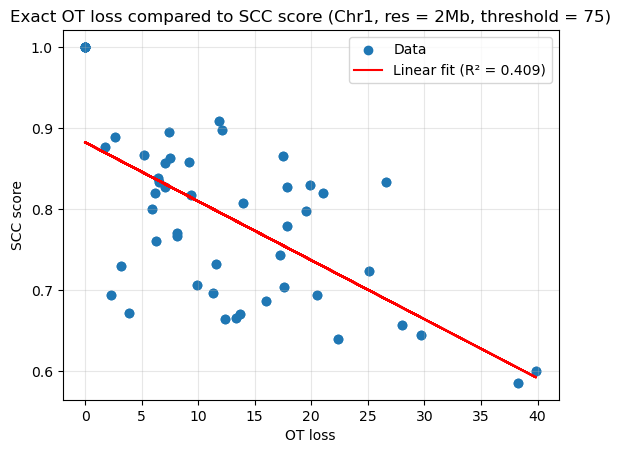

In [56]:
### SCC Comparison ###
df_2mb_75, rsqr_2mb_75 = compare_to_scc(exact_2mb_75, 75, 2)
save_df_to_csv(df_2mb_75, 2, 75)

#### Compiling R^2 values

In [34]:
rsqr_2mb_dict = {
    0 : rsqr_2mb_0,
    25 : rsqr_2mb_25,
    50 : rsqr_2mb_50,
    75 : rsqr_2mb_75
}

### Resolution = 1 Mb

In [35]:
### Binning ###
chr1_binned_1mb = []
for chr1 in chr1s:
    chr1_binned_1mb.append(bin_contact_map(chr1, 1))

#### Threshold = 50

In [36]:
### OT ###
exact_1mb_50 = []

for chr1 in chr1_binned_1mb:
    exact_1mb_50.append(hic_ot_source_to_targets(chr1, chr1_binned_1mb, 50, 'percentile', 'sum'))

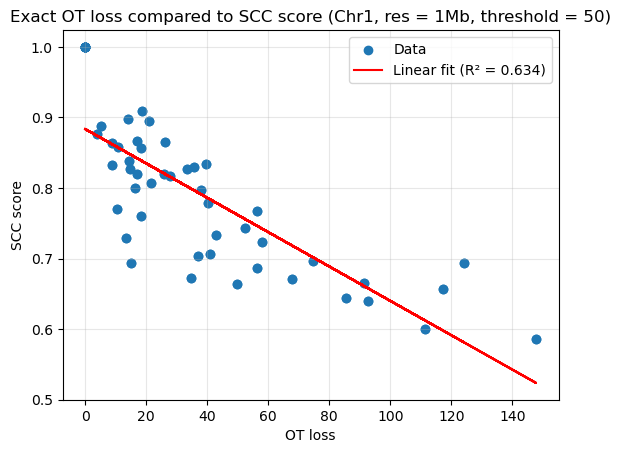

In [57]:
### SCC Comparison ###
df_1mb_50, rsqr_1mb_50 = compare_to_scc(exact_1mb_50, 50, 1)
save_df_to_csv(df_1mb_50, 1, 50)

#### Threshold = 75

In [38]:
### OT ###
exact_1mb_75 = []

for chr1 in chr1_binned_1mb:
    exact_1mb_75.append(hic_ot_source_to_targets(chr1, chr1_binned_1mb, 75, 'percentile', 'sum'))

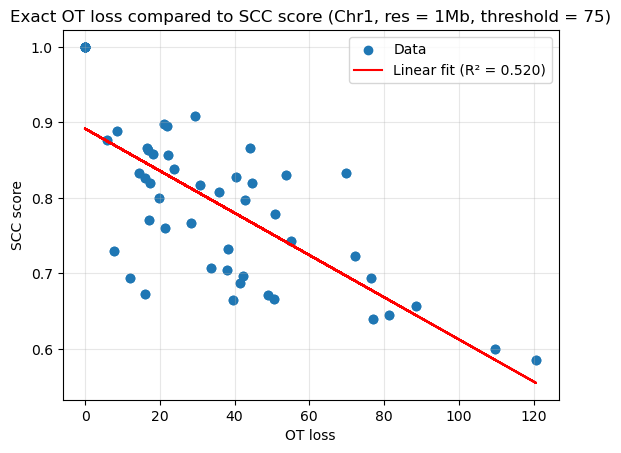

In [58]:
### SCC Comparison ###
df_1mb_75, rsqr_1mb_75 = compare_to_scc(exact_1mb_75, 75, 1)
save_df_to_csv(df_1mb_75, 1, 75)

#### Compiling R^2 values

In [40]:
rsqr_1mb_dict = {
    50 : rsqr_1mb_50,
    75 : rsqr_1mb_75
}

### Comparisons

#### Computation times
These results are based on the time stamps in the notebook, meaning they are most likely inaccurate.

In [73]:
### Putting in Dataframe ###
comp_times = [
    [0.3, 0.2, 0.0, 0.0],
    [14.7, 7.0, 2.6, 0.5],
    [1003.3, 194.7, 71.3, 12.6],
    [np.nan, np.nan, 1356.3, 358.0]
]
resolutions = ["8 Mb", "4 Mb", "2 Mb", "1 Mb"]
percentiles = [0, 25 ,50, 75]
comp_times_df = pd.DataFrame(comp_times, index=resolutions, 
                             columns=["0% OT loss", "25% OT loss", "50% OT loss", "75% OT loss"])
comp_times_df

,0% OT loss,25% OT loss,50% OT loss,75% OT loss
8 Mb,0.3,0.2,0.0,0.0
4 Mb,14.7,7.0,2.6,0.5
2 Mb,1003.3,194.7,71.3,12.6
1 Mb,NaN,NaN,1356.3,358.0


#### R^2 values

In [71]:
### Compiling all ###
rsqr_values = [
    [rsqr_8mb_0, rsqr_8mb_25, rsqr_8mb_50, rsqr_8mb_75],
    [rsqr_4mb_0, rsqr_4mb_25, rsqr_4mb_50, rsqr_4mb_75],
    [rsqr_2mb_0, rsqr_2mb_25, rsqr_2mb_50, rsqr_2mb_75],
    [np.nan, np.nan, rsqr_1mb_50, rsqr_1mb_75]
]
rsqr_df = pd.DataFrame(rsqr_values, index=resolutions, 
                        columns=["0% R\u00b2", "25% R\u00b2", "50% R\u00b2", "75% R\u00b2"])
rsqr_df

,0% R²,25% R²,50% R²,75% R²
8 Mb,0.675022,0.666897,0.603700,0.064458
4 Mb,0.642973,0.636228,0.598409,0.311156
2 Mb,0.627980,0.624533,0.626590,0.408637
1 Mb,NaN,NaN,0.633546,0.519846


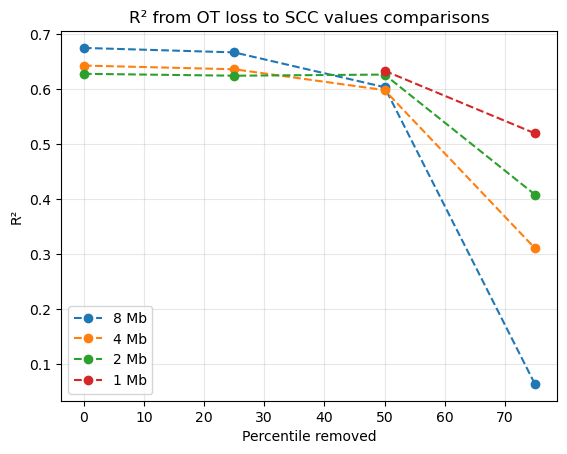

In [ ]:
### Plotting, x = percentile ###
for res in resolutions:
    plt.plot(percentiles, rsqr_df.loc[res, :].values, "--o", label=res)
plt.xlabel("Percentile removed")
plt.ylabel("R\u00b2")
plt.title("R\u00b2 from OT loss to SCC values comparisons")
plt.legend()
plt.grid(alpha=0.3)

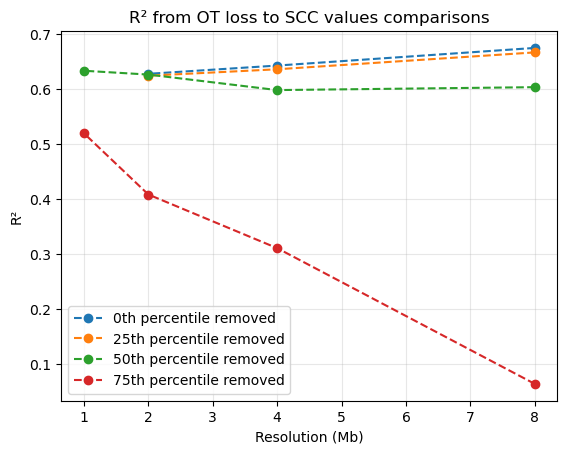

In [135]:
### Plotting, x = resolution ###
reses = [8, 4, 2, 1]
for per in percentiles:
    plt.plot(reses, rsqr_df.loc[:, f"{per}% R\u00b2"].values, "--o", label=f"{per}th percentile removed")
plt.xlabel("Resolution (Mb)")
plt.ylabel("R\u00b2")
plt.title("R\u00b2 from OT loss to SCC values comparisons")
plt.legend()
plt.grid(alpha=0.3)

#### Correspondence between OT results

Text(0, 0.5, 'OT Loss (1 Mb, 50%)')

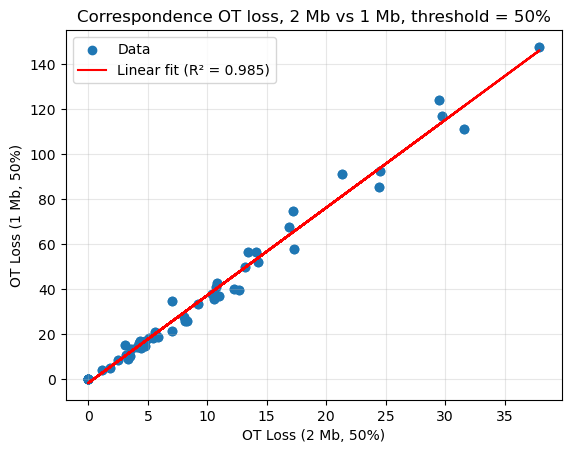

In [127]:
### Example Comparison 2 Mb and 1 Mb with 50% ###
calculate_correspondence(df_2mb_50, df_1mb_50, True)
plt.title("Correspondence OT loss, 2 Mb vs 1 Mb, threshold = 50%")
plt.xlabel("OT Loss (2 Mb, 50%)")
plt.ylabel("OT Loss (1 Mb, 50%)")

In [131]:
### Correspondence all comparisons ###
# Organizing data
dataframes = {
    ('8 Mb', 0): df_8mb_0,
    ('8 Mb', 25): df_8mb_25,
    ('8 Mb', 50): df_8mb_50,
    ('8 Mb', 75): df_8mb_75,
    ('4 Mb', 0): df_4mb_0,
    ('4 Mb', 25): df_4mb_25,
    ('4 Mb', 50): df_4mb_50,
    ('4 Mb', 75): df_4mb_75,
    ('2 Mb', 0): df_2mb_0,
    ('2 Mb', 25): df_2mb_25,
    ('2 Mb', 50): df_2mb_50,
    ('2 Mb', 75): df_2mb_75,
    ('1 Mb', 50): df_1mb_50,
    ('1 Mb', 75): df_1mb_75
}

    # Vectorizing data
data_vectors = {}
for key, df in dataframes.items():
    vec = df.stack()
    data_vectors[key] = vec
vector_df = pd.DataFrame(data_vectors)

# Calculating R^2 
results_rsqr = []
cols = vector_df.columns

for col1 in cols:
    for col2 in cols:
        x = vector_df[col1].values
        y = vector_df[col2].values
        regression = linregress(x, y)
        r2 = regression.rvalue**2
        results_rsqr.append((col1, col2, r2))

r2_df = pd.DataFrame(results_rsqr, columns=["matrix_1", "matrix_2", "R\u00b2"])
r2_df['matrix_1'] = r2_df['matrix_1'].apply(lambda x: f"{x[0]}_{x[1]}")
r2_df['matrix_2'] = r2_df['matrix_2'].apply(lambda x: f"{x[0]}_{x[1]}")
r2_matrix = r2_df.pivot(index="matrix_1", columns="matrix_2", values="R\u00b2")
r2_matrix

matrix_2,1 Mb_50,1 Mb_75,2 Mb_0,2 Mb_25,2 Mb_50,2 Mb_75,4 Mb_0,4 Mb_25,4 Mb_50,4 Mb_75,8 Mb_0,8 Mb_25,8 Mb_50,8 Mb_75
matrix_1,,,,,,,,,,,,,,
1 Mb_50,1.000000,0.826357,0.933359,0.978923,0.984642,0.647259,0.934157,0.979870,0.929540,0.493625,0.932819,0.953014,0.876897,0.132902
1 Mb_75,0.826357,1.000000,0.629615,0.716414,0.900944,0.935793,0.642489,0.731326,0.948512,0.855183,0.664679,0.779554,0.942892,0.392556
2 Mb_0,0.933359,0.629615,1.000000,0.978779,0.881923,0.447098,0.996580,0.971151,0.795779,0.294737,0.984060,0.909137,0.730070,0.040085
2 Mb_25,0.978923,0.716414,0.978779,1.000000,0.938411,0.529866,0.977611,0.994983,0.856129,0.373044,0.967211,0.938363,0.795226,0.076796
2 Mb_50,0.984642,0.900944,0.881923,0.938411,1.000000,0.747713,0.889056,0.944334,0.975577,0.602970,0.896363,0.939885,0.930628,0.183568
2 Mb_75,0.647259,0.935793,0.447098,0.529866,0.747713,1.000000,0.460116,0.550525,0.824219,0.945591,0.484485,0.621166,0.821655,0.453184
4 Mb_0,0.934157,0.642489,0.996580,0.977611,0.889056,0.460116,1.000000,0.972454,0.807822,0.307427,0.993837,0.915020,0.747796,0.042222
4 Mb_25,0.979870,0.731326,0.971151,0.994983,0.944334,0.550525,0.972454,1.000000,0.870044,0.393957,0.969229,0.960130,0.819160,0.084894
4 Mb_50,0.929540,0.948512,0.795779,0.856129,0.975577,0.824219,0.807822,0.870044,1.000000,0.710591,0.827429,0.906131,0.973040,0.240666


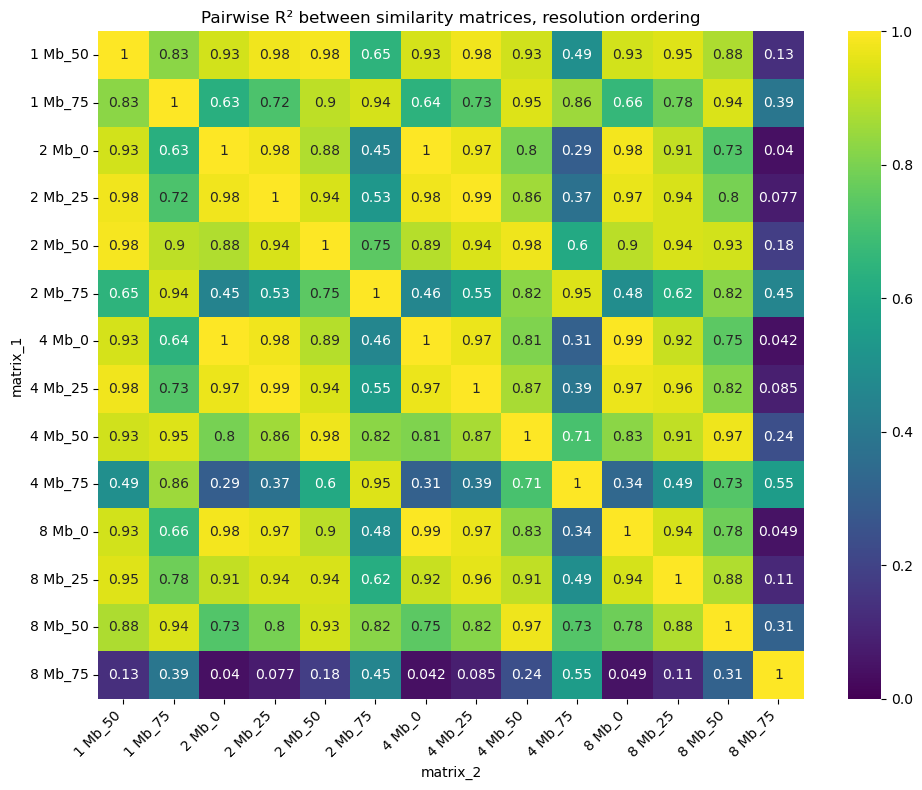

In [140]:
### Plotting R2 values ###
plt.figure(figsize=(10,8))
sns.heatmap(r2_matrix, annot=True, cmap="viridis", vmin=0, vmax=1)
plt.title("Pairwise R\u00b2 between similarity matrices, resolution ordering")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

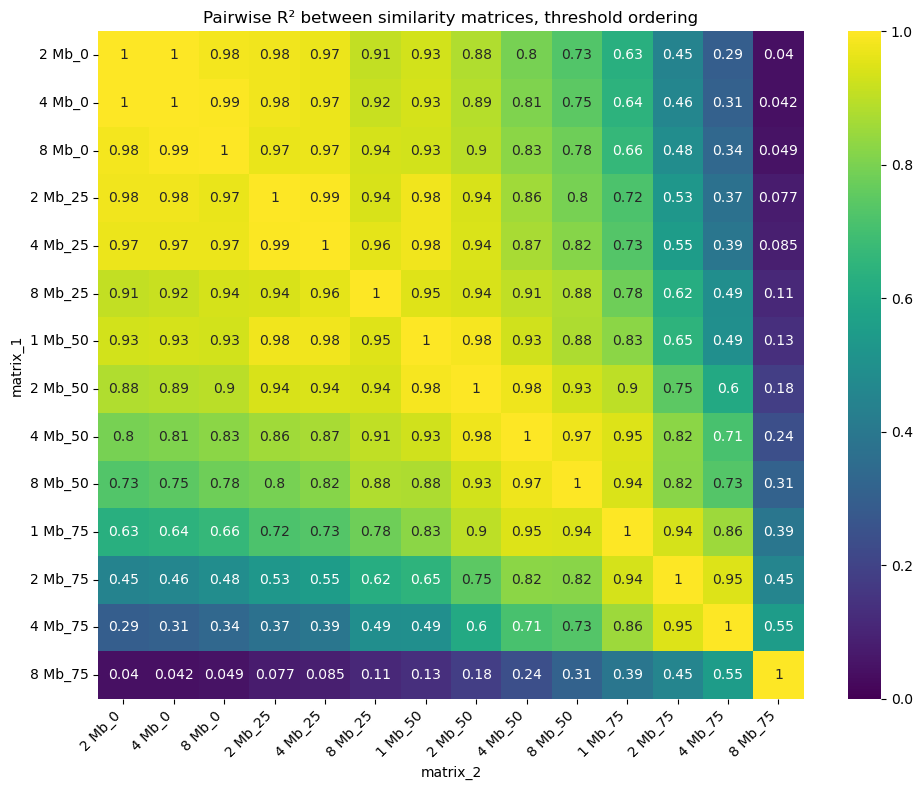

In [141]:
### Plotting with threshold first ordering ###
order = sorted(r2_df['matrix_1'].unique(), key=lambda x: (int(x.split('_')[1]), int(x.split('Mb_')[0])))
r2_matrix_thres = r2_matrix.loc[order, order]
plt.figure(figsize=(10,8))
sns.heatmap(r2_matrix_thres, annot=True, cmap="viridis", vmin=0, vmax=1)
plt.title("Pairwise R\u00b2 between similarity matrices, threshold ordering")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()